In [8]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import torch
import pandas as pd
import numpy as np
from torch import nn, optim
from torch.nn import functional as F
import os
import pickle

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


from utils.calibration_plots import calc_bins, get_ECE_metrics

%matplotlib inline

C:\Users\d.c.macrae\AppData\Local\Temp\2\ipykernel_9900\3191523651.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [9]:
def get_and_filter_preds(df, endpoint):
    preds = df[endpoint + '_pred']
    labels = df[endpoint + '_true']

    mask = labels.isin([0, 1])

    preds = preds[mask]
    labels = labels[mask]

    preds = torch.tensor(preds.values)
    labels = torch.tensor(labels.values)

    preds_logits = torch.log(preds / (1 - preds))

    return preds_logits, preds, labels

In [10]:
%load_ext autoreload

exp_dir = r"Z:/Daniel/TransRP Experiments 2/TransRP_DenseNet121_m2 FIX"
model_name = 'TransRP_DenseNet121_m2'

# exp_dir = r"C:\Users\d.c.macrae\Documents\DL_NTCP_Multitox\final_models_2\Best_ResNet_2"
# model_name = 'resnet_lrelu'

endpoints = ['Aspiration_M06', 'Dysphagia_M06', 'Sticky_M06', 'Taste_M06', 'Xerostomia_M06']

folders = os.listdir(exp_dir)


all_preds_df_dict = {endpoint: {} for endpoint in endpoints}
lr_all_preds_df_dict = {endpoint: {} for endpoint in endpoints}

dl_ens_preds_dict = {endpoint: None for endpoint in endpoints}
lr_ens_preds_dict = {endpoint: None for endpoint in endpoints}
#scaled_ens_preds_dict = {endpoint: None for endpoint in endpoints}
true_labels_dict = {endpoint: None for endpoint in endpoints}

for model_n, folder in enumerate(folders):
    #print(folder)
    df_preds_dir = os.path.join(exp_dir, folder, model_name + '_all_outputs.csv')
    df_lr_preds_dir = os.path.join(exp_dir, folder,  '_lr_all_outputs.csv')
    df_preds = pd.read_csv(df_preds_dir, delimiter=';')
    df_lr_preds = pd.read_csv(df_lr_preds_dir, delimiter=';')
    df_val = df_preds[df_preds['Mode'] == 'val']
    df_test = df_preds[df_preds['Mode'] == 'test']
    df_lr_val = df_lr_preds[df_lr_preds['Mode'] == 'val']
    df_lr_test = df_lr_preds[df_lr_preds['Mode'] == 'test']


    for endpoint in endpoints:
        # first find the scaling by using the validation set
        val_logits, val_preds, val_labels = get_and_filter_preds(df_val, endpoint)
        lr_val_logits, lr_val_preds, lr_val_labels = get_and_filter_preds(df_lr_val, endpoint)

        test_logits, test_preds, test_labels = get_and_filter_preds(df_test, endpoint)
        lr_test_logits, lr_test_preds, lr_test_labels = get_and_filter_preds(df_lr_test, endpoint)

        # save each model's predictions
        all_preds_df_dict[endpoint][str(model_n)] = test_preds
        lr_all_preds_df_dict[endpoint][str(model_n)] = lr_test_preds


        if dl_ens_preds_dict[endpoint] is None:
            dl_ens_preds_dict[endpoint] = test_preds/5
            lr_ens_preds_dict[endpoint] = lr_test_preds/5
            true_labels_dict[endpoint] = test_labels
        else:
            dl_ens_preds_dict[endpoint] += test_preds/5
            lr_ens_preds_dict[endpoint] += lr_test_preds/5


all_preds_df_dict = {endpoint: pd.DataFrame(all_preds_df_dict[endpoint]) for endpoint in endpoints}
lr_all_preds_df_dict = {endpoint: pd.DataFrame(lr_all_preds_df_dict[endpoint]) for endpoint in endpoints}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
ST_models_dir = r"C:\Users\d.c.macrae\Documents\DL_NTCP_Multitox\Single Tox Models"
models = os.listdir(ST_models_dir)

ST_ens_preds_dict = {endpoint: None for endpoint in endpoints}
ST_all_preds_df_dict = {endpoint: {} for endpoint in endpoints}


for model in models:
    print(model)
    toxicity = model.split(' ')[-1]
    if toxicity == "Xerostomia":
        model_name = "dcnn_pooling"
        endpoint = "Xerostomia_M06"
    elif toxicity == "Dysphagia":
        model_name = "resnet_lrelu"
        endpoint = "Dysphagia_M06"
    elif toxicity == "Taste":
        model_name = "resnet_dcnn_lrelu"
        endpoint = "Taste_M06"
    else:
        continue


    print(endpoint)
    ST_ens_preds_dict[endpoint] = None

    exp_dir = os.path.join(ST_models_dir, model)

    folders = os.listdir(exp_dir)

    

    #scaled_ens_preds_dict = {endpoint: None for endpoint in endpoints}
    ST_true_labels_dict = {endpoint: None for endpoint in endpoints}

    for model_n, folder in enumerate(folders):
        #print(folder)
        df_preds_dir = os.path.join(exp_dir, folder, model_name + '_all_outputs.csv')
        #df_lr_preds_dir = os.path.join(exp_dir, folder,  '_lr_all_outputs.csv')
        df_preds = pd.read_csv(df_preds_dir, delimiter=';')
        #df_lr_preds = pd.read_csv(df_lr_preds_dir, delimiter=';')
        df_val = df_preds[df_preds['Mode'] == 'val']
        df_test = df_preds[df_preds['Mode'] == 'test']
        #df_lr_val = df_lr_preds[df_lr_preds['Mode'] == 'val']
        #df_lr_test = df_lr_preds[df_lr_preds['Mode'] == 'test']

        #print(len(df_val), len(df_test))


        # first find the scaling by using the validation set
        val_logits, val_preds, val_labels = get_and_filter_preds(df_val, endpoint)

        test_logits, test_preds, test_labels = get_and_filter_preds(df_test, endpoint)

        # save each model's predictions
        ST_all_preds_df_dict[endpoint][str(model_n)] = test_preds
        #print(ST_all_preds_df_dict[endpoint][str(model_n)])



        if ST_ens_preds_dict[endpoint] is None:
            ST_ens_preds_dict[endpoint] = test_preds/5
            ST_true_labels_dict[endpoint] = test_labels
        else:
            ST_ens_preds_dict[endpoint] += test_preds/5



    ST_all_preds_df_dict = {endpoint: pd.DataFrame(ST_all_preds_df_dict[endpoint]) for endpoint in endpoints}
    

Hendrike Taste
Taste_M06
Hung Xerostomia
Xerostomia_M06
Mixup Hung Xerostomia
Xerostomia_M06
Mixup Suzanne Dysphagia
Dysphagia_M06
Suzanne Dysphagia
Dysphagia_M06


In [12]:
# leon's functions:
import numpy as np

def calculate_predictive_entropy(predictions):
    """
    Calculate the predictive entropy of the predictions.
    :param predictions: DataFrame containing the predictions of the models.
    :return: Series containing the predictive entropy.
    """
    mean = predictions.mean(axis=1)
    entropy = - (mean * np.log(mean + 1e-10) + (1 - mean) * np.log(1 - mean + 1e-10))
    return np.round(entropy, 4)

def calculate_aleatoric_uncertainty(predictions):
    """
    Calculate the aleatoric uncertainty of the predictions.

    Aleatoric uncertainty captures the uncertainty inherent in the data.
    Estimated by the variance of the predictions.

    :param predictions: DataFrame containing the predictions of the models.
    :return: Series containing the aleatoric uncertainty.
    """
    aleatoric_uncertainty = np.mean(predictions * (1 - predictions), axis=1)
    #aleatoric_uncertainty = np.var(predictions, axis=1, ddof=1)
    return aleatoric_uncertainty


def calculate_epistemic_uncertainty(predictions):
    """
    Calculate the epistemic uncertainty of the predictions.

    Epistemic uncertainty captures the uncertainty due in the model parameters.
    Estimated by the variance of mean predictions

    :param predictions: DataFrame containing the predictions of the models.
    :return: Series containing the epistemic uncertainty.
    """

    # Only if not already a numpy array
    if not isinstance(predictions, np.ndarray):
        predictions_np = predictions.to_numpy()  # Convert DataFrame to numpy array
    else:
        predictions_np = predictions

    
    #predictions_np = np.log(predictions_np) - np.log(1 - predictions_np)

    return np.mean(predictions_np ** 2, axis=1) - np.mean(predictions_np, axis=1) ** 2

Aspiration_M06
Dysphagia_M06
Sticky_M06
Taste_M06
Xerostomia_M06


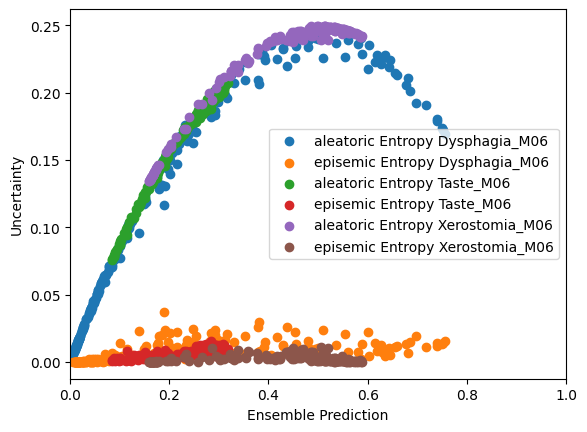

In [13]:
for endpoint in endpoints:
    print(endpoint)
    if ST_ens_preds_dict[endpoint] is None:
        continue 

    
    aleatoric_uncertainty = calculate_aleatoric_uncertainty(ST_all_preds_df_dict[endpoint])
    epistemic_uncertainty = calculate_epistemic_uncertainty(ST_all_preds_df_dict[endpoint])

    #epistemic_unc = pred_entropy - expected_entropy
    #epistemic_uncertainty = calculate_epistemic_uncertainty(all_preds_df_dict[endpoint])
    #aleatoric_uncertainty = calculate_aleatoric_uncertainty(all_preds_df_dict[endpoint])

    ens_preds = ST_ens_preds_dict[endpoint]

    #print(endpoint, np.mean(epistemic_unc))
    
    plt.scatter(ens_preds, aleatoric_uncertainty, label=f'aleatoric Entropy {endpoint}')
    plt.scatter(ens_preds, epistemic_uncertainty, label=f'episemic Entropy {endpoint}')
    #plt.scatter(ens_preds, expected_entropy, label=f'Expected Entropy {endpoint}')
    #plt.scatter(ens_preds, epistemic_uncertainty, label=f'Epistemic Uncertainty {endpoint}')
    plt.xlabel('Ensemble Prediction')
    plt.ylabel('Uncertainty')
    plt.legend()
    #plt.title(endpoint)

plt.xlim(0, 1)
#plt.ylim(0, 0.4)
plt.show()

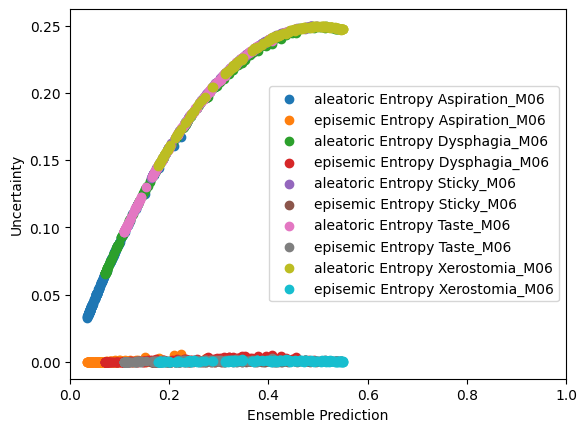

In [14]:
for endpoint in endpoints:
    aleatoric_uncertainty = calculate_aleatoric_uncertainty(all_preds_df_dict[endpoint])
    epistemic_uncertainty = calculate_epistemic_uncertainty(all_preds_df_dict[endpoint])

    #epistemic_unc = pred_entropy - expected_entropy
    #epistemic_uncertainty = calculate_epistemic_uncertainty(all_preds_df_dict[endpoint])
    #aleatoric_uncertainty = calculate_aleatoric_uncertainty(all_preds_df_dict[endpoint])

    ens_preds = dl_ens_preds_dict[endpoint]

    #print(endpoint, np.mean(epistemic_unc))
    
    plt.scatter(ens_preds, aleatoric_uncertainty, label=f'aleatoric Entropy {endpoint}')
    plt.scatter(ens_preds, epistemic_uncertainty, label=f'episemic Entropy {endpoint}')
    #plt.scatter(ens_preds, expected_entropy, label=f'Expected Entropy {endpoint}')
    #plt.scatter(ens_preds, epistemic_uncertainty, label=f'Epistemic Uncertainty {endpoint}')
    plt.xlabel('Ensemble Prediction')
    plt.ylabel('Uncertainty')
    plt.legend()
    #plt.title(endpoint)

plt.xlim(0, 1)
#plt.ylim(0, 0.4)
plt.show()

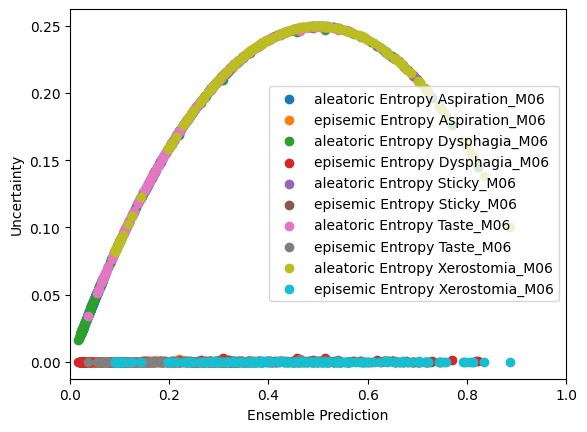

In [15]:
for endpoint in endpoints:
    aleatoric_uncertainty = calculate_aleatoric_uncertainty(lr_all_preds_df_dict[endpoint])
    epistemic_uncertainty = calculate_epistemic_uncertainty(lr_all_preds_df_dict[endpoint])

    #epistemic_uncertainty = np.var(lr_all_preds_df_dict[endpoint], axis=1, ddof=1)

    #epistemic_unc = pred_entropy - expected_entropy
    #epistemic_uncertainty = calculate_epistemic_uncertainty(all_preds_df_dict[endpoint])
    #aleatoric_uncertainty = calculate_aleatoric_uncertainty(all_preds_df_dict[endpoint])

    ens_preds = lr_ens_preds_dict[endpoint]

    #print(endpoint, np.mean(epistemic_unc))
    
    plt.scatter(ens_preds, aleatoric_uncertainty, label=f'aleatoric Entropy {endpoint}')
    plt.scatter(ens_preds, epistemic_uncertainty, label=f'episemic Entropy {endpoint}')
    #plt.scatter(ens_preds, expected_entropy, label=f'Expected Entropy {endpoint}')
    #plt.scatter(ens_preds, epistemic_uncertainty, label=f'Epistemic Uncertainty {endpoint}')
    plt.xlabel('Ensemble Prediction')
    plt.ylabel('Uncertainty')
    plt.legend()
    #plt.title(endpoint)

plt.xlim(0, 1)
#plt.ylim(0, 0.4)
plt.show()

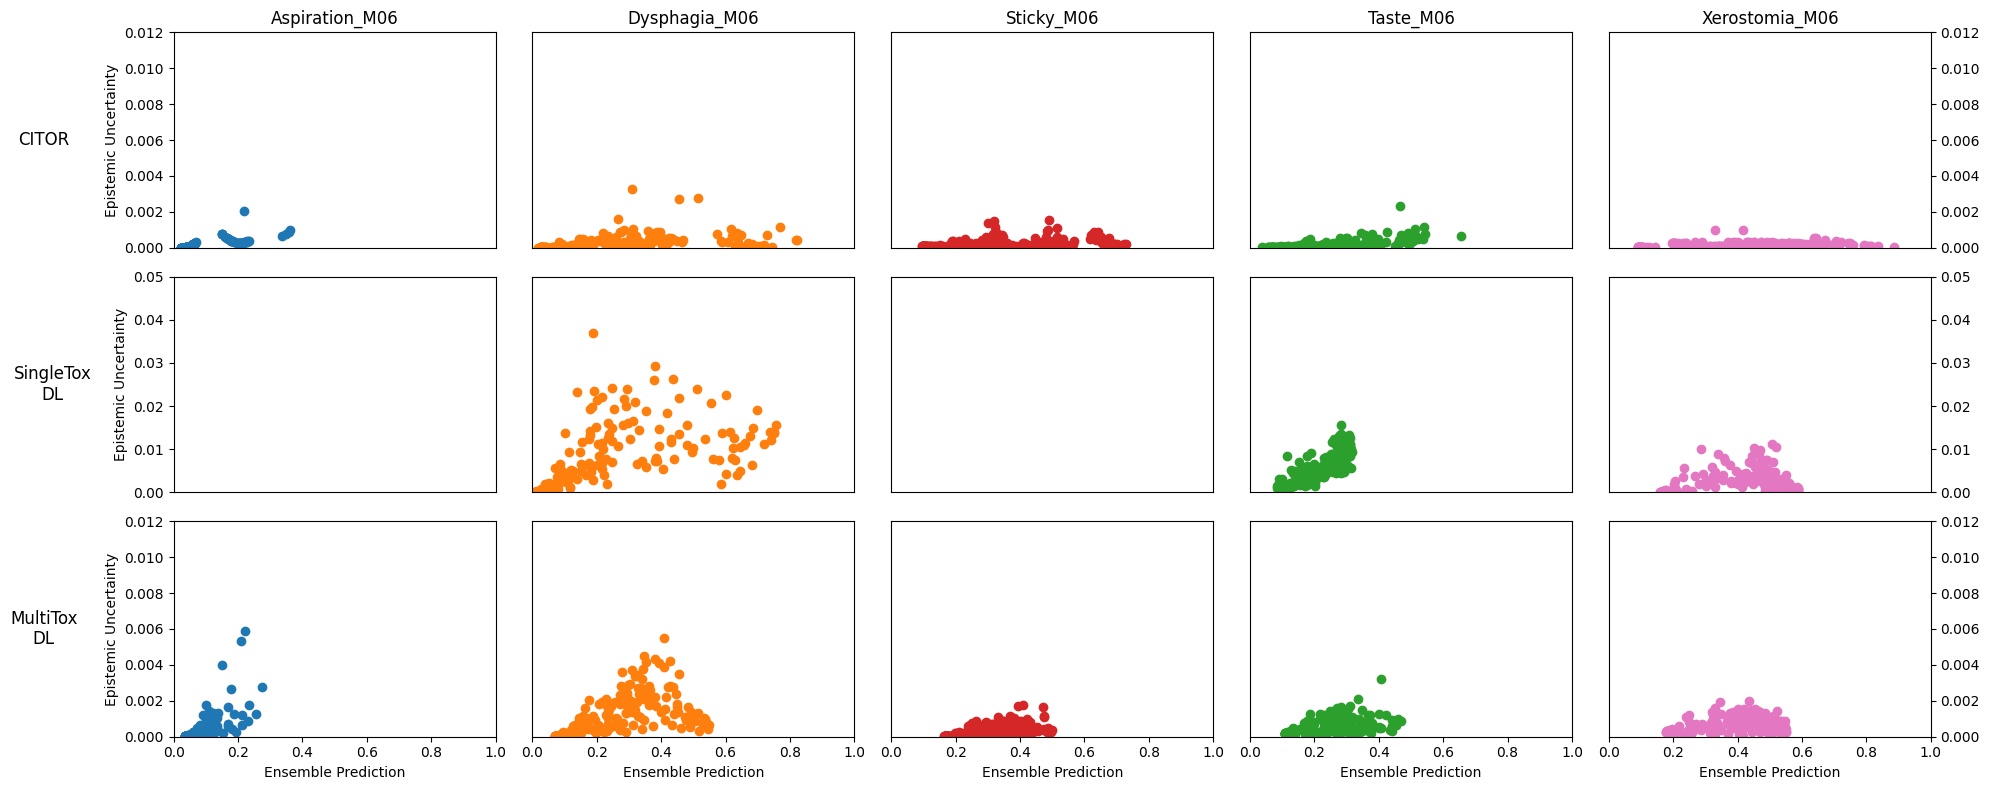

In [17]:
import matplotlib.pyplot as plt


# Create a figure and axes for subplots
row_count = 3
n_endpoints = len(endpoints)
fig, axes = plt.subplots(nrows=row_count, ncols=n_endpoints, figsize=(4*n_endpoints, 8))

colours = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:cyan']

# Iterate over endpoints and plot subplots
for i in range(row_count):
    #print(i)
    if i == 0:
        all_predictions_df_dict = lr_all_preds_df_dict
        ens_predictions_dict = lr_ens_preds_dict
    elif i == 1:
        all_predictions_df_dict = ST_all_preds_df_dict
        ens_predictions_dict = ST_ens_preds_dict
    else:
        all_predictions_df_dict = all_preds_df_dict
        ens_predictions_dict = dl_ens_preds_dict

    for j, endpoint in enumerate(endpoints):
        if ens_predictions_dict[endpoint] is None:
            #fig.delaxes(axes[i,j])
            continue

        # Select the data for the current endpoint
        epistemic_uncertainty = calculate_epistemic_uncertainty(all_predictions_df_dict[endpoint])

        axes[i,j].scatter(ens_predictions_dict[endpoint], epistemic_uncertainty, label=f'aleatoric uncertainty {endpoint}', c=colours[j])


# Set axes labels
for i in range(row_count):
    for j in range(n_endpoints):
        # applied to all
        axes[i,j].set_xlim(0, 1)
        

        if i == 1:
            axes[i,j].set_ylim(0, 0.05)
        else:
            axes[i,j].set_ylim(0, 0.012)


        if j == 0:
            axes[i,j].set_ylabel("Epistemic Uncertainty")
        elif j == n_endpoints - 1:
            axes[i,j].yaxis.tick_right()
        else: 
            axes[i,j].yaxis.set_visible(False)

        if i == row_count - 1:
            axes[i,j].set_xlabel("Ensemble Prediction")
        else:
            axes[i,j].xaxis.set_visible(False)

        if i == 0:
            axes[i,j].set_title(endpoints[j])

# Add titles to each row
labels = ['CITOR', "SingleTox\nDL", "MultiTox\nDL"]
for i, ax in enumerate(axes):
    ax[0].annotate(
        labels[i],
        xy=(0, 0.5),
        xytext=(-ax[0].yaxis.labelpad - 40, 0),
        xycoords=ax[0].yaxis.label,
        textcoords="offset points",
        size="large",
        ha="center",
        va="center",
    )

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

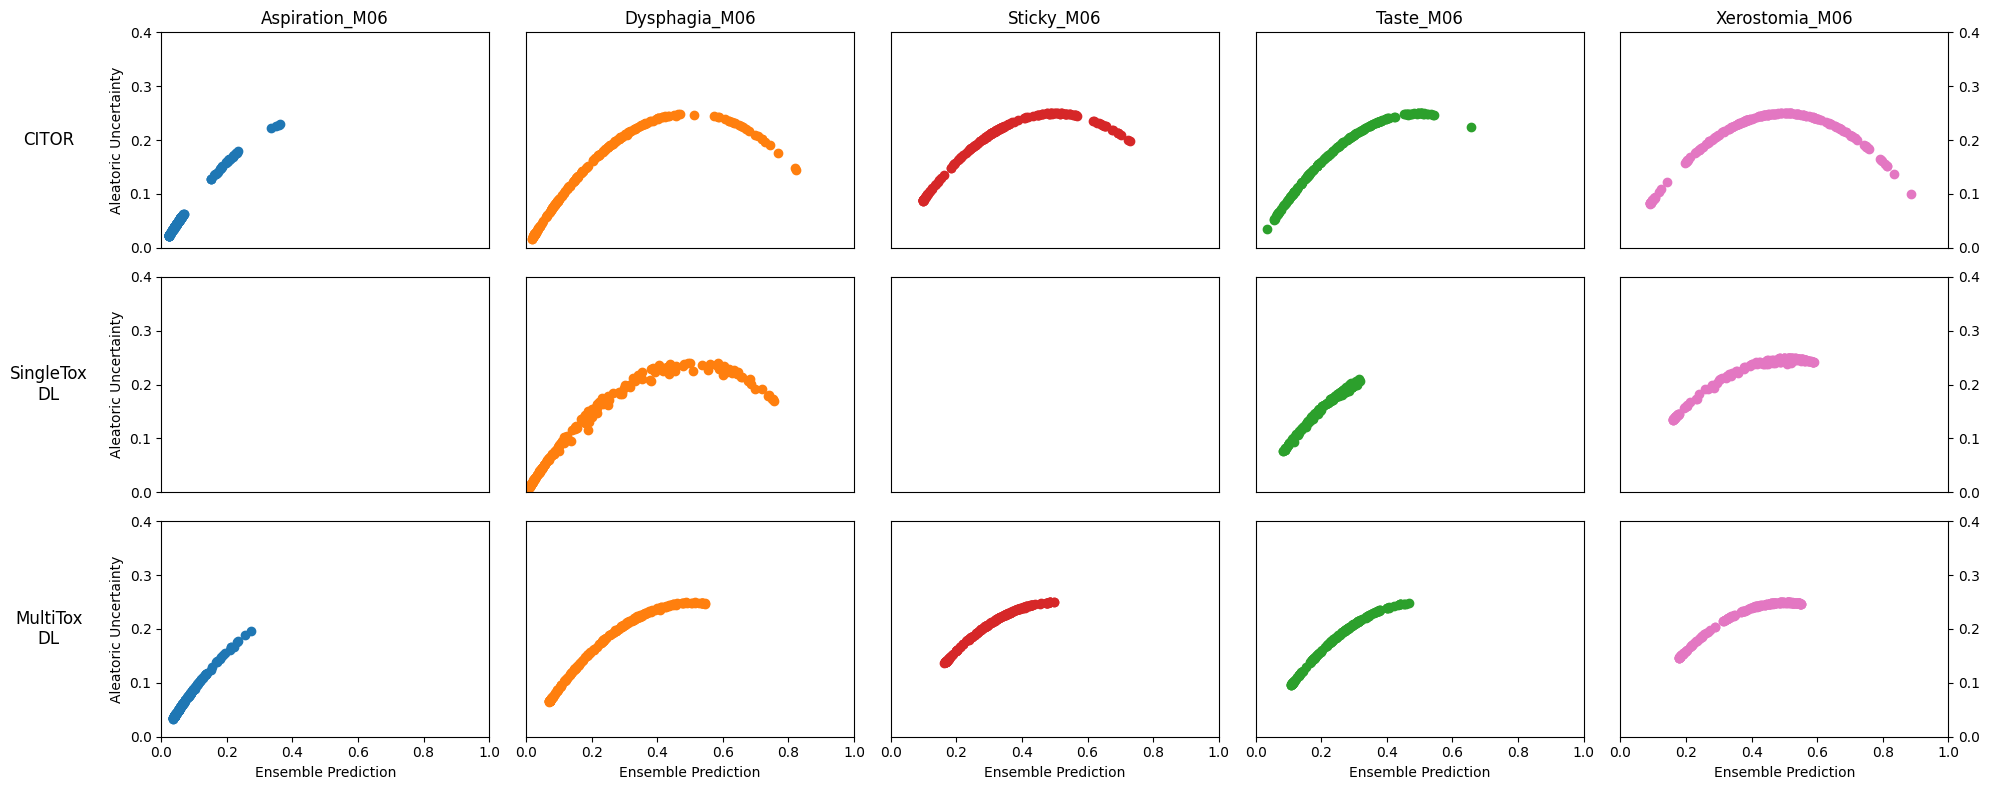

In [19]:
import matplotlib.pyplot as plt

# Create a figure and axes for subplots
row_count = 3
n_endpoints = len(endpoints)
fig, axes = plt.subplots(nrows=row_count, ncols=n_endpoints, figsize=(4*n_endpoints, 8))

colours = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:cyan']

# Iterate over endpoints and plot subplots
for i in range(row_count):
    #print(i)
    if i == 0:
        all_predictions_df_dict = lr_all_preds_df_dict
        ens_predictions_dict = lr_ens_preds_dict
    elif i == 1:
        all_predictions_df_dict = ST_all_preds_df_dict
        ens_predictions_dict = ST_ens_preds_dict
    else:
        all_predictions_df_dict = all_preds_df_dict
        ens_predictions_dict = dl_ens_preds_dict

    for j, endpoint in enumerate(endpoints):
        if ens_predictions_dict[endpoint] is None:
            #fig.delaxes(axes[i,j])
            continue

        # Select the data for the current endpoint
        epistemic_uncertainty = calculate_aleatoric_uncertainty(all_predictions_df_dict[endpoint])

        axes[i,j].scatter(ens_predictions_dict[endpoint], epistemic_uncertainty, label=f'aleatoric uncertainty {endpoint}', c=colours[j])


# Set axes labels
for i in range(row_count):
    for j in range(n_endpoints):
        # applied to all
        axes[i,j].set_xlim(0, 1)
        axes[i,j].set_ylim(0, 0.4)

        if j == 0:
            axes[i,j].set_ylabel("Aleatoric Uncertainty")
        elif j == n_endpoints - 1:
            axes[i,j].yaxis.tick_right()
        else: 
            axes[i,j].yaxis.set_visible(False)

        if i == row_count - 1:
            axes[i,j].set_xlabel("Ensemble Prediction")
        else:
            axes[i,j].xaxis.set_visible(False)

        if i == 0:
            axes[i,j].set_title(endpoints[j])

# Add titles to each row
labels = ['CITOR', "SingleTox\nDL", "MultiTox\nDL"]
for i, ax in enumerate(axes):
    ax[0].annotate(
        labels[i],
        xy=(0, 0.5),
        xytext=(-ax[0].yaxis.labelpad - 40, 0),
        xycoords=ax[0].yaxis.label,
        textcoords="offset points",
        size="large",
        ha="center",
        va="center",
    )

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

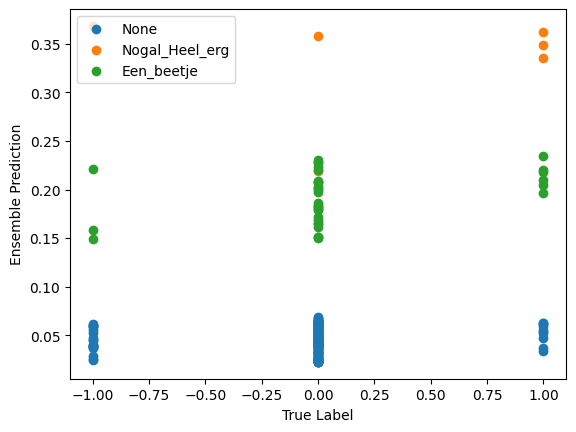

In [ ]:
df_lr_ens = pd.read_csv(os.path.join(exp_dir,'5_101_27_TransRP_DenseNet121_m2_params_99836481_auc_tr_0.739_val_0.737_test_0.733_avg_tr_0.748_val_0.725_test_0.732_ens_0.738', 'lr_ens_outputs.csv'), delimiter=';')
df_lr_ens['PatientID'] = [str(item).zfill(7) for item in df_lr_ens["PatientID"]]

df_strat_split = pd.read_csv(r"C:\Users\d.c.macrae\Documents\DL_NTCP_Multitox\datasets\MT_dataset\stratified_sampling_test_542.csv", delimiter=';')
df_strat_split['PatientID'] = [str(item).zfill(7) for item in df_strat_split["PatientID"]]

df_aspiration = pd.merge(df_lr_ens, df_strat_split, on='PatientID', how='left')

df_aspiration_groups = df_aspiration.groupby(['Aspiration_W01_Een_beetje', 'Aspiration_W01_Nogal_Heel_erg'])
df_aspiration_groups["Aspiration_M06_pred"].mean()


for name, group in df_aspiration_groups:
    #print(name)
    if name == (0, 0): 
        name = "None"
    elif name == (0, 1):
        name = "Nogal_Heel_erg"
    elif name == (1, 0):
        name = "Een_beetje"
    plt.scatter(group["Aspiration_M06_true"], group["Aspiration_M06_pred"], label=name)

plt.xlabel('True Label')
plt.ylabel('Ensemble Prediction')
plt.legend()
plt.show()